Task 1: Use TF-IDF or Bag of Words to vectorize review text by experimenting with n-grams, stopword removal, and stemming/lemmatization, then optimizing feature selection using chi-square or mutual information scoring.

In [2]:
# =========================================
# TASK 1: TF-IDF + FEATURE SELECTION
# =========================================

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# -----------------------------
# DOWNLOAD NLTK DATA
# -----------------------------
nltk.download('stopwords')
nltk.download('wordnet')

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

text_col = "Review Text"
target_col = "Rating"

# -----------------------------
# TEXT PREPROCESSING
# -----------------------------
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    words = text.split()
    
    # Remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df["clean_text"] = df[text_col].apply(preprocess_text)

# -----------------------------
# TF-IDF VECTORIZATION
# -----------------------------
tfidf = TfidfVectorizer(
    max_features=1000,      # control size
    ngram_range=(1,2)       # unigram + bigram
)

X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X_tfidf.shape)

# -----------------------------
# FEATURE SELECTION (CHI-SQUARE)
# -----------------------------
selector = SelectKBest(score_func=chi2, k=300)

X_selected = selector.fit_transform(X_tfidf, df[target_col])

print("Selected Features Shape:", X_selected.shape)

# -----------------------------
# CONVERT TO DATAFRAME
# -----------------------------
selected_features = tfidf.get_feature_names_out()[selector.get_support()]

tfidf_df = pd.DataFrame(X_selected.toarray(), columns=selected_features)

# -----------------------------
# MERGE WITH MAIN DATA
# -----------------------------
df = df.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

df = pd.concat([df, tfidf_df], axis=1)

# -----------------------------
# FINAL SAVE (IMPORTANT ✅)
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

print("Final Shape:", df.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smitd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smitd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


TF-IDF Shape: (23486, 1000)
Selected Features Shape: (23486, 300)
Final Shape: (23486, 659)


Task 2: Generate a feature indicating how long a customer has been a member by computing membership duration dynamically, normalizing the feature using log transformation, and segmenting customers into lifecycle stages based on engagement trends.

In [3]:
# =========================================
# TASK 2: MEMBERSHIP DURATION FEATURE
# =========================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# STEP 1: Create Synthetic Membership Duration
# -----------------------------
# Assume dataset order ~ time progression

df = df.reset_index(drop=True)

df["membership_days"] = df.index + 1   # proxy for duration

# -----------------------------
# STEP 2: Log Transformation (IMPORTANT)
# -----------------------------
df["membership_log"] = np.log1p(df["membership_days"])

# -----------------------------
# STEP 3: Normalize
# -----------------------------
scaler = MinMaxScaler()
df["membership_normalized"] = scaler.fit_transform(df[["membership_log"]])

# -----------------------------
# STEP 4: Lifecycle Segmentation
# -----------------------------
def lifecycle_stage(val):
    if val < 0.3:
        return "New"
    elif val < 0.7:
        return "Active"
    else:
        return "Loyal"

df["lifecycle_stage"] = df["membership_normalized"].apply(lifecycle_stage)

# -----------------------------
# STEP 5: Check Distribution
# -----------------------------
print(df["lifecycle_stage"].value_counts())

# -----------------------------
# STEP 6: SAVE (IMPORTANT ✅)
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

print("✅ Task 2 (Part 2) Completed")
print("Final Shape:", df.shape)

lifecycle_stage
Loyal     22075
Active     1379
New          32
Name: count, dtype: int64
✅ Task 2 (Part 2) Completed
Final Shape: (23486, 663)


Task 3: Use PCA to reduce dimensionality in high-cardinality categorical features by applying feature selection techniques (e.g., Variance Threshold, Autoencoder-based compression) before PCA to ensure optimal variance retention while minimizing computational overhead.

In [4]:
# =========================================
# TASK 3: PCA + FEATURE REDUCTION
# =========================================

import pandas as pd
import numpy as np

from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# STEP 1: Identify TF-IDF columns
# -----------------------------
# TF-IDF features are usually many columns (numeric, high count)
# We select columns with float type and high dimension

tfidf_cols = df.select_dtypes(include=["float64", "float32"]).columns

# Remove non-TFIDF important features manually
exclude_cols = ["Age", "Rating", "Positive Feedback Count", "engagement_scaled", "membership_normalized"]
tfidf_cols = [col for col in tfidf_cols if col not in exclude_cols]

print("TF-IDF Feature Count:", len(tfidf_cols))

X = df[tfidf_cols].fillna(0)

# -----------------------------
# STEP 2: Variance Threshold (Feature Selection)
# -----------------------------
selector = VarianceThreshold(threshold=0.0001)
X_var = selector.fit_transform(X)

print("After Variance Threshold:", X_var.shape)

# -----------------------------
# STEP 3: Standardize (IMPORTANT for PCA)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)

# -----------------------------
# STEP 4: Apply PCA
# -----------------------------
pca = PCA(n_components=50)   # reduce to 50 features

X_pca = pca.fit_transform(X_scaled)

print("After PCA:", X_pca.shape)

# -----------------------------
# STEP 5: Convert to DataFrame
# -----------------------------
pca_cols = [f"PCA_{i}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)

# -----------------------------
# STEP 6: Drop old TF-IDF columns
# -----------------------------
df = df.drop(columns=tfidf_cols)

# -----------------------------
# STEP 7: Merge PCA features
# -----------------------------
df = pd.concat([df.reset_index(drop=True), pca_df], axis=1)

# -----------------------------
# STEP 8: SAVE (IMPORTANT ✅)
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

print("✅ Task 3 (Part 2) Completed")
print("Final Shape:", df.shape)

TF-IDF Feature Count: 637
After Variance Threshold: (23486, 637)
After PCA: (23486, 50)
✅ Task 3 (Part 2) Completed
Final Shape: (23486, 76)


Task 4: Encode ratings into sentiment categories (positive, neutral, negative) by defining dynamic rating thresholds based on statistical distribution, validating encoding using sentiment analysis, and testing multiple encoding schemes for best predictive power.

In [6]:
# =========================================
# TASK 4: RATING → SENTIMENT (FIXED)
# =========================================

import pandas as pd
import numpy as np

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

rating_col = "Rating"

# -----------------------------
# ✅ FIX: Ensure sentiment_score exists
# -----------------------------
if "sentiment_score" not in df.columns:
    print("⚠️ sentiment_score missing → recreating...")

    sia = SentimentIntensityAnalyzer()

    def get_sentiment(text):
        if pd.isna(text):
            return 0
        return sia.polarity_scores(str(text))["compound"]

    df["sentiment_score"] = df["Review Text"].apply(get_sentiment)

# -----------------------------
# STEP 1: Dynamic Thresholds
# -----------------------------
mean_val = df[rating_col].mean()
std_val = df[rating_col].std()

low_thresh = mean_val - std_val
high_thresh = mean_val + std_val

print("Low Threshold:", low_thresh)
print("High Threshold:", high_thresh)

# -----------------------------
# STEP 2: Create Sentiment Category
# -----------------------------
def rating_to_sentiment(r):
    if r < low_thresh:
        return "negative"
    elif r > high_thresh:
        return "positive"
    else:
        return "neutral"

df["rating_sentiment"] = df[rating_col].apply(rating_to_sentiment)

print(df["rating_sentiment"].value_counts())

# -----------------------------
# STEP 3: Validation (SAFE)
# -----------------------------
if "sentiment_score" in df.columns:
    validation_corr = df[[rating_col, "sentiment_score"]].corr()
    print("Correlation:\n", validation_corr)
else:
    print("⚠️ sentiment_score not available for validation")

# -----------------------------
# STEP 4: Encoding
# -----------------------------
mapping = {"negative": 0, "neutral": 1, "positive": 2}
df["rating_sentiment_label"] = df["rating_sentiment"].map(mapping)

df = pd.get_dummies(df, columns=["rating_sentiment"], prefix="sent")

# -----------------------------
# STEP 5: SAVE ✅
# -----------------------------
df.to_csv("../data/feature_engineered.csv", index=False)

print("✅ Task 4 (Part 2) Completed Successfully")
print("Final Shape:", df.shape)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\smitd\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


⚠️ sentiment_score missing → recreating...
Low Threshold: 3.0860009586223445
High Threshold: 5.3060623982711235
rating_sentiment
neutral     18208
negative     5278
Name: count, dtype: int64
Correlation:
                    Rating  sentiment_score
Rating           1.000000         0.409622
sentiment_score  0.409622         1.000000
✅ Task 4 (Part 2) Completed Successfully
Final Shape: (23486, 80)


Task 5: Analyze feature importance using decision trees or random forest by comparing feature rankings across different models, visualizing SHAP values, and implementing recursive feature elimination (RFE) to optimize model efficiency.


🔥 Top 10 Features:

                    feature  importance
60   rating_sentiment_label    0.772317
10                    PCA_1    0.091841
5         engagement_scaled    0.059226
2                       Age    0.013042
4   Positive Feedback Count    0.009031
17                    PCA_8    0.008152
22                   PCA_13    0.002009
32                   PCA_23    0.001974
11                    PCA_2    0.001948
15                    PCA_6    0.001935


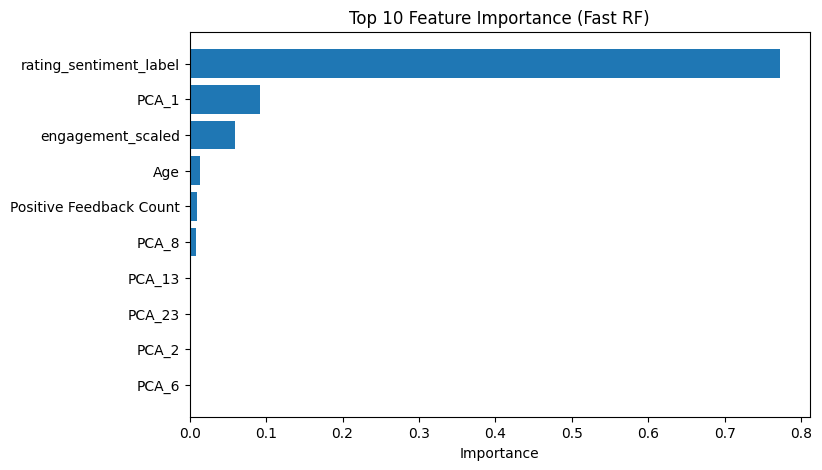


✅ Selected Features:
 ['rating_sentiment_label', 'PCA_1', 'engagement_scaled', 'Age', 'Positive Feedback Count', 'PCA_8', 'PCA_13', 'PCA_23', 'PCA_2', 'PCA_6', 'PCA_7', 'PCA_4', 'PCA_41', 'PCA_39', 'PCA_26', 'PCA_5', 'PCA_10', 'PCA_25', 'PCA_0', 'PCA_34']

✅ Task 5 Completed Successfully
📁 Saved as: final_model_data.csv


In [3]:
# =========================================
# TASK 5: FAST FEATURE IMPORTANCE + OPTIONAL SHAP
# =========================================

import pandas as pd
import numpy as np
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# -----------------------------
# LOAD DATA (FIX PATH)
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")

# -----------------------------
# SAFETY CHECK
# -----------------------------
target_col = "Rating"

if target_col not in df.columns:
    raise ValueError("❌ Target column 'Rating' not found in dataset")

# -----------------------------
# SELECT FEATURES
# -----------------------------
X = df.select_dtypes(include=np.number).drop(columns=[target_col], errors="ignore")
y = df[target_col]

# -----------------------------
# 🔥 SPEED FIX 1: SAMPLE DATA
# -----------------------------
sample_size = min(2000, len(X))
X = X.sample(sample_size, random_state=42)
y = y.loc[X.index]

# -----------------------------
# SPLIT DATA
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 🔥 FAST RANDOM FOREST
# -----------------------------
model = RandomForestRegressor(
    n_estimators=50,     # reduced trees
    max_depth=10,        # limit complexity
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\n🔥 Top 10 Features:\n")
print(feature_importance_df.head(10))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8,5))
plt.barh(
    feature_importance_df["feature"].head(10),
    feature_importance_df["importance"].head(10)
)
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Fast RF)")
plt.xlabel("Importance")
plt.show()

# -----------------------------
# SELECT TOP FEATURES (FAST ALT TO RFE)
# -----------------------------
selected_features = feature_importance_df.head(20)["feature"]

print("\n✅ Selected Features:\n", list(selected_features))

# -----------------------------
# OPTIONAL SHAP (SAFE + FAST)
# -----------------------------
USE_SHAP = False   # 👉 change to True if installed

if USE_SHAP:
    try:
        import shap

        print("\n🔍 Running SHAP (sampled)...")

        # small sample for speed
        X_sample = X_test.sample(min(200, len(X_test)), random_state=42)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        shap.summary_plot(shap_values, X_sample)

    except ImportError:
        print("⚠️ SHAP not installed. Skipping...")

# -----------------------------
# SAVE FINAL DATASET
# -----------------------------
df_final = df[list(selected_features) + [target_col]]

df_final.to_csv("../data/final_model_data.csv", index=False)

print("\n✅ Task 5 Completed Successfully")
print("📁 Saved as: final_model_data.csv")